# InternNova — Data Analytics Internship
## Week 6 Assignment: Exploratory Data Analysis & Visualizations
**Dataset:** `sales_data_cleaned.csv`  \
**Prepared by:** Brojo Mohan Dutta\
**Environment:** Anaconda / Jupyter Notebook 7.4.5 / Python 3.x / Pandas

# Setup & Load Data

#### Explaination: 
Imports the required Python libraries and loads the cleaned sales dataset into a Pandas DataFrame.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_data_cleaned.csv")
df.head()

,sale_id,order_date,product_id,region,payment_method,quantity,unit_price,sales_amount,product_name,category,unit_cost,total_cost,profit
0,5001,2024-06-01,P05,West,Debit Card,9,3299.0,29691.0,Webcam HD,Electronics,2200,19800,9891.0
1,5002,2024-06-03,P10,North,Debit Card,4,14999.0,59996.0,Gaming Chair,Furniture,8900,35600,24396.0
2,5003,2024-06-05,P07,West,UPI,8,6999.0,55992.0,Noise Cancelling Headphones,Electronics,4200,33600,22392.0
3,5004,2024-06-07,P04,South,Debit Card,8,1999.0,15992.0,Laptop Stand,Accessories,1100,8800,7192.0
4,5005,2024-06-09,P04,West,UPI,5,1999.0,9995.0,Laptop Stand,Accessories,1100,5500,4495.0


#### Result:
The cleaned sales dataset was successfully loaded, and the first five records were displayed. The dataset contains sales transaction details along with product information and calculated cost and profit fields.

# Data Inspection

#### Explanation
Initial inspection of the dataset by checking its dimensions, column names, data types, missing values, duplicate records, and unique region values. This helps identify the structure and potential data-quality issues before performing further analysis.

In [19]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Data Types:\n", df.dtypes)
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Unique region values:", df["region"].unique())

Shape: (60, 13)
Columns: ['sale_id', 'order_date', 'product_id', 'region', 'payment_method', 'quantity', 'unit_price', 'sales_amount', 'product_name', 'category', 'unit_cost', 'total_cost', 'profit']
Data Types:
 sale_id             int64
order_date         object
product_id         object
region             object
payment_method     object
quantity            int64
unit_price        float64
sales_amount      float64
product_name       object
category           object
unit_cost           int64
total_cost          int64
profit            float64
dtype: object
Missing values:
 sale_id           0
order_date        0
product_id        0
region            0
payment_method    0
quantity          0
unit_price        0
sales_amount      0
product_name      0
category          0
unit_cost         0
total_cost        0
profit            0
dtype: int64
Duplicate rows: 0
Unique region values: ['West' 'North' 'South' 'East']


#### Result
The inspection shows that the dataset contains 60 rows and 14 columns. The dataset includes numerical, categorical, and date-related fields. The order_date column is stored as a datetime type, while fields such as product_id, region, payment_method, product_name, and category are categorical/object fields.

# Descriptive Statistics

#### Explanation: 
Summarizes central tendency and spread for the key numeric fields.

In [20]:
# Convert order_date from text to datetime
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Create month abbreviation for analysis
df["month"] = df["order_date"].dt.strftime("%b")

# Display descriptive statistics for key numerical variables
print("Descriptive Statistics:")
print(df[["quantity", "unit_price", "sales_amount", "profit"]].describe())

Descriptive Statistics:
        quantity    unit_price   sales_amount        profit
count  60.000000     60.000000      60.000000     60.000000
mean    4.483333   6039.000000   25030.516667  10103.016667
std     2.758602   4553.828711   24582.516448   9766.505637
min     1.000000    799.000000     799.000000    349.000000
25%     2.000000   1999.000000    6998.750000   3055.500000
50%     4.500000   5249.000000   16743.500000   7641.500000
75%     7.000000   8499.000000   35246.250000  14246.500000
max     9.000000  14999.000000  104993.000000  42693.000000


#### Key results: 
Average sale ₹25,030.52, average profit ₹10,103.02 per transaction, max single sale ₹1,04,993 (Gaming Chair).

# Correlation Analysis

#### Explanation: 
Checks linear relationships between the numeric fields.

In [21]:
correlation_matrix = df[["quantity", "unit_price", "sales_amount", "profit"]].corr()
print(correlation_matrix)

              quantity  unit_price  sales_amount    profit
quantity      1.000000   -0.165495      0.473542  0.476659
unit_price   -0.165495    1.000000      0.656382  0.654595
sales_amount  0.473542    0.656382      1.000000  0.997871
profit        0.476659    0.654595      0.997871  1.000000


#### Findings: 
sales_amount and profit are almost perfectly correlated (0.998) — expected, since profit is derived directly from sales revenue minus a proportional cost. unit_price correlates moderately with sales_amount (0.656), stronger than quantity does (0.474) — meaning higher-priced items drive more revenue variation than order size does in this dataset.

# Outlier Detection

#### Explanation: 
Uses the IQR method on sales_amount to flag unusually large transactions.

In [22]:
Q1 = df["sales_amount"].quantile(0.25)
Q3 = df["sales_amount"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["sales_amount"] < lower_bound) | (df["sales_amount"] > upper_bound)]
print("Upper bound:", upper_bound)
print(outliers[["sale_id", "product_name", "quantity", "sales_amount"]])

Upper bound: 77617.5
    sale_id  product_name  quantity  sales_amount
7      5008  Gaming Chair         7      104993.0
10     5011  Gaming Chair         6       89994.0


#### Findings: 
Two Gaming Chair transactions (sale_id 5008: ₹1,04,993 and sale_id 5011: ₹89,994) exceed the upper IQR bound (₹77,617.50) — both are high-quantity bulk orders of the highest-cost item, not data errors, so they're kept as genuine (if unusual) large sales.

# Patterns & Trends Summary

#### Explanation: 
Aggregates by the key business dimensions to surface patterns feeding into Task 5's visuals and Task 7's insights.

In [23]:
month_order = ["Jun", "Jul", "Aug", "Sep"]

print("Sales by month:\n", df.groupby("month")["sales_amount"].sum().reindex(month_order))
print("Sales by region:\n", df.groupby("region")["sales_amount"].sum().sort_values(ascending=False))
print("Sales by payment method:\n", df.groupby("payment_method")["sales_amount"].sum().sort_values(ascending=False))
print("Sales by category:\n", df.groupby("category")["sales_amount"].sum().sort_values(ascending=False))

Sales by month:
 month
Jun    643016.0
Jul    376741.0
Aug    297530.0
Sep    184544.0
Name: sales_amount, dtype: float64
Sales by region:
 region
South    414840.0
East     410239.0
West     342917.0
North    333835.0
Name: sales_amount, dtype: float64
Sales by payment method:
 payment_method
UPI                 404902.0
Debit Card          403224.0
Cash on Delivery    398254.0
Credit Card         295451.0
Name: sales_amount, dtype: float64
Sales by category:
 category
Storage        509940.0
Furniture      329978.0
Electronics    254046.0
Wearables      208981.0
Accessories    198886.0
Name: sales_amount, dtype: float64


#### Brief explanation of findings: 
Sales declined every month (Jun ₹6,43,016 → Sep ₹1,84,544). South (₹4,14,840) leads regions; Storage (34%) leads categories; UPI (₹4,04,902) leads payment methods, though the top 3 payment methods are closely clustered while Credit Card trails noticeably.

# Data Visualization

### Line Chart — Monthly Sales Trend

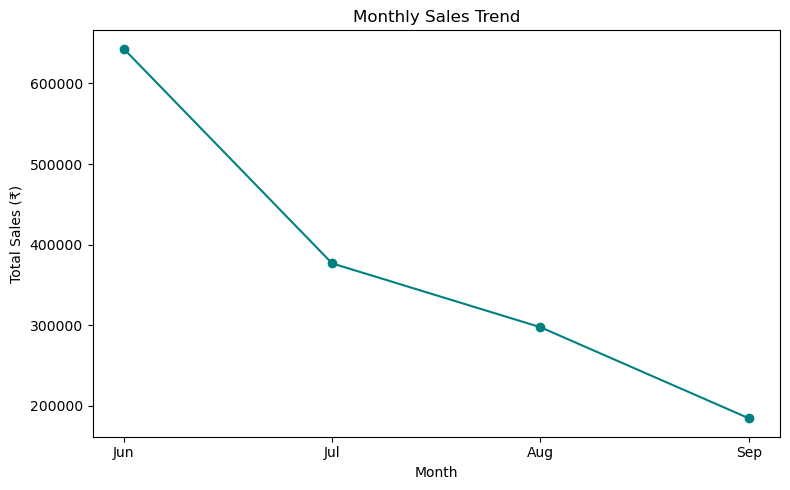

In [24]:
monthly_sales = df.groupby("month")["sales_amount"].sum().reindex(month_order)

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", color="teal")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (₹)")
plt.tight_layout()
plt.show()

#### Explanation: 
Shows a steep, consistent revenue decline from June through September — the most important trend in the dataset.

### Bar Chart — Total Sales by Region

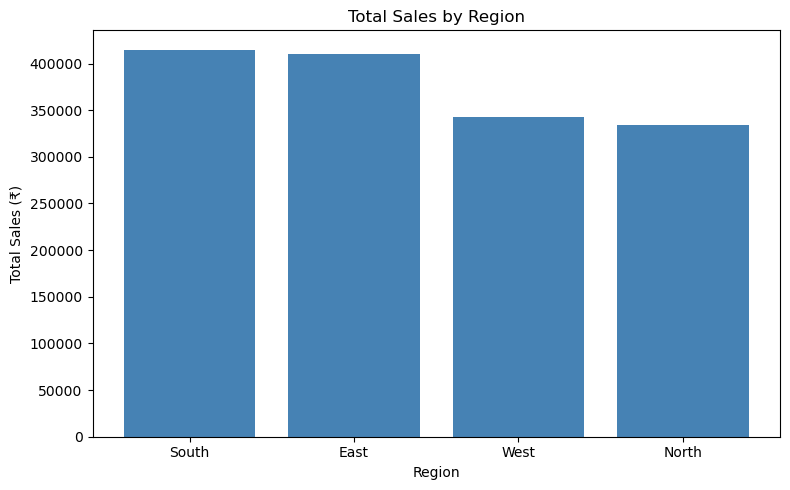

In [25]:
region_sales = df.groupby("region")["sales_amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values, color="steelblue")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales (₹)")
plt.tight_layout()
plt.show()

#### Explanation: 
South and East lead regional performance; North trails all four regions.

### Pie Chart — Sales Share by Category

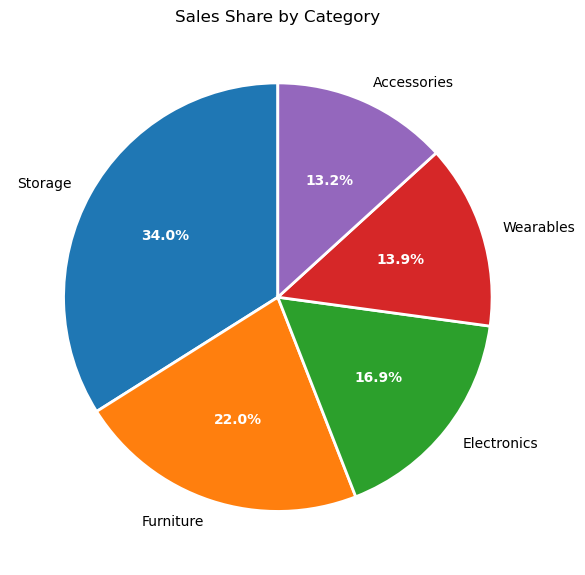

In [46]:
category_sales = df.groupby("category")["sales_amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
plt.title("Sales Share by Category")
plt.tight_layout()
plt.show()

#### Explanation: 
Storage dominates at 34% of total revenue, more than double Wearables or Accessories individually.

### Histogram — Distribution of Sales Amount

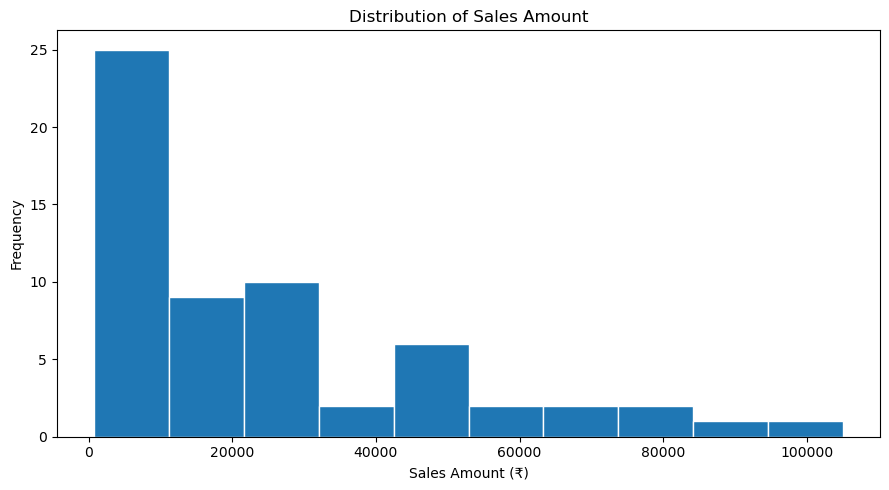

In [42]:
plt.figure(figsize=(9, 5))
plt.hist(df["sales_amount"], bins=10, edgecolor="white")
plt.title("Distribution of Sales Amount")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Explanation: 
Shows the shape of the 60 transaction values — most cluster in the lower-to-mid range (25th–75th percentile: ₹6,998.75–₹35,246.25), with a long right tail from a handful of high-value bulk orders. This visually confirms the mean (₹25,030.52) sits above the median (₹16,743.50), consistent with the right-skewed distribution (skewness ≈ 1.38) already noted in the descriptive statistics.

### Box Plot — Sales Amount Distribution by Category

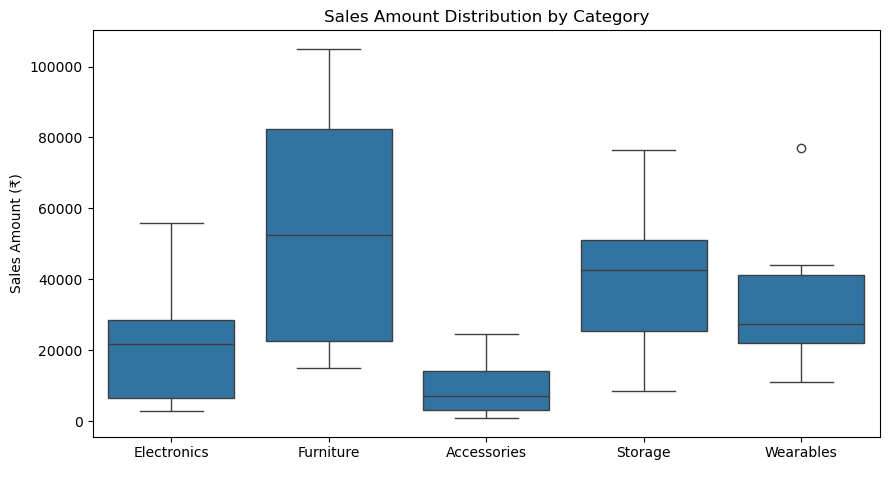

In [44]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="category", y="sales_amount")
plt.title("Sales Amount Distribution by Category")
plt.xlabel(" ")
plt.ylabel("Sales Amount (₹)")
plt.tight_layout()
plt.show()

#### Explanation: 
Adds a spread view beyond the category donut chart's share-of-total view. Furniture shows the widest spread and highest single transaction (₹1,04,993 — the bulk Gaming Chair order) despite ranking second in total revenue, while Accessories clusters tightly at the low end (median ₹6,998). This shows category performance isn't just about total revenue — some categories are driven by consistent mid-size orders, others by occasional large ones.

### Count Plot — Transactions by Payment Method

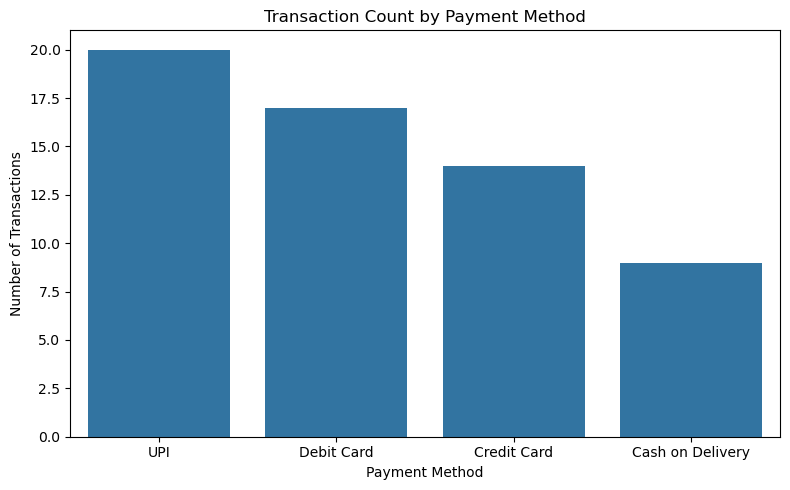

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="payment_method", order=df["payment_method"].value_counts().index)
plt.title("Transaction Count by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

#### Explanation: 
Shows how many individual transactions used each payment method — a volume view that complements the revenue-by-payment-method figure from the Power BI dashboard.

### Scatter Plot — Unit Price vs Sales Amount

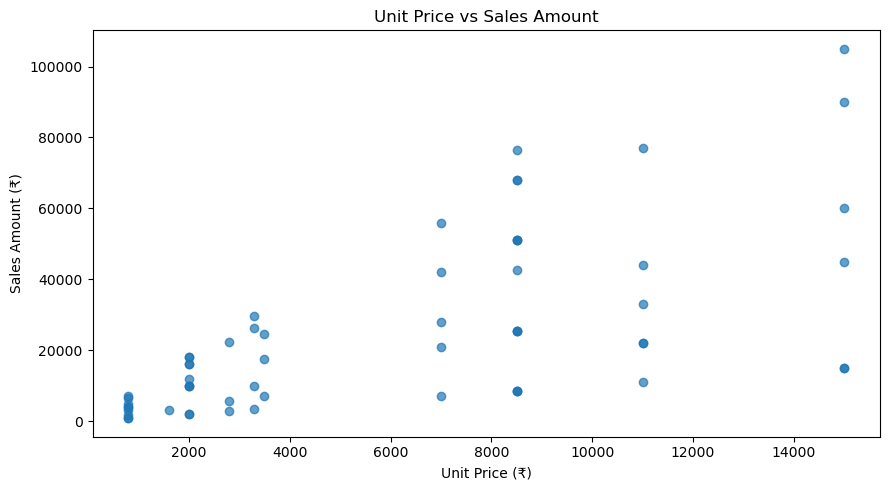

In [45]:
plt.figure(figsize=(9, 5))
plt.scatter(df["unit_price"], df["sales_amount"], alpha=0.7)
plt.title("Unit Price vs Sales Amount")
plt.xlabel("Unit Price (₹)")
plt.ylabel("Sales Amount (₹)")
plt.tight_layout()
plt.show()

#### Explanation: 
Visualizes the moderate positive relationship (r = 0.656) between price and revenue per transaction — confirming price is a stronger revenue driver than quantity (r = 0.474) in this dataset, though the relationship isn't perfectly linear since sales_amount is also a function of units sold.

### Heatmap — Correlation Between Numeric Variables

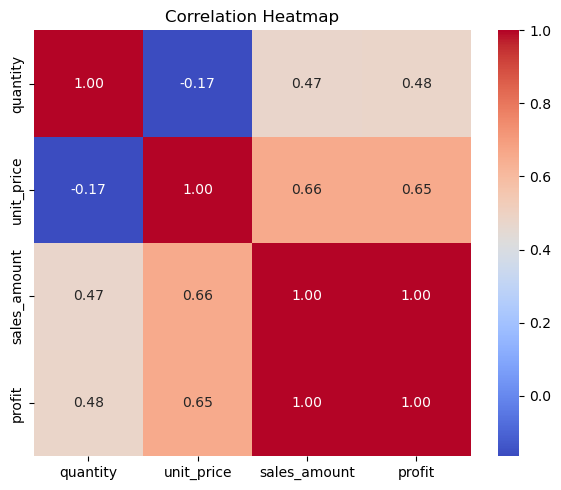

In [28]:
plt.figure(figsize=(6,5))
sns.heatmap(df[["quantity", "unit_price", "sales_amount", "profit"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#### Explanation: 
Visually confirms sales_amount and profit move almost in lockstep (0.998), and highlights unit_price as a stronger revenue driver than quantity alone.